/tmp/ipykernel_1154/3802100067.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


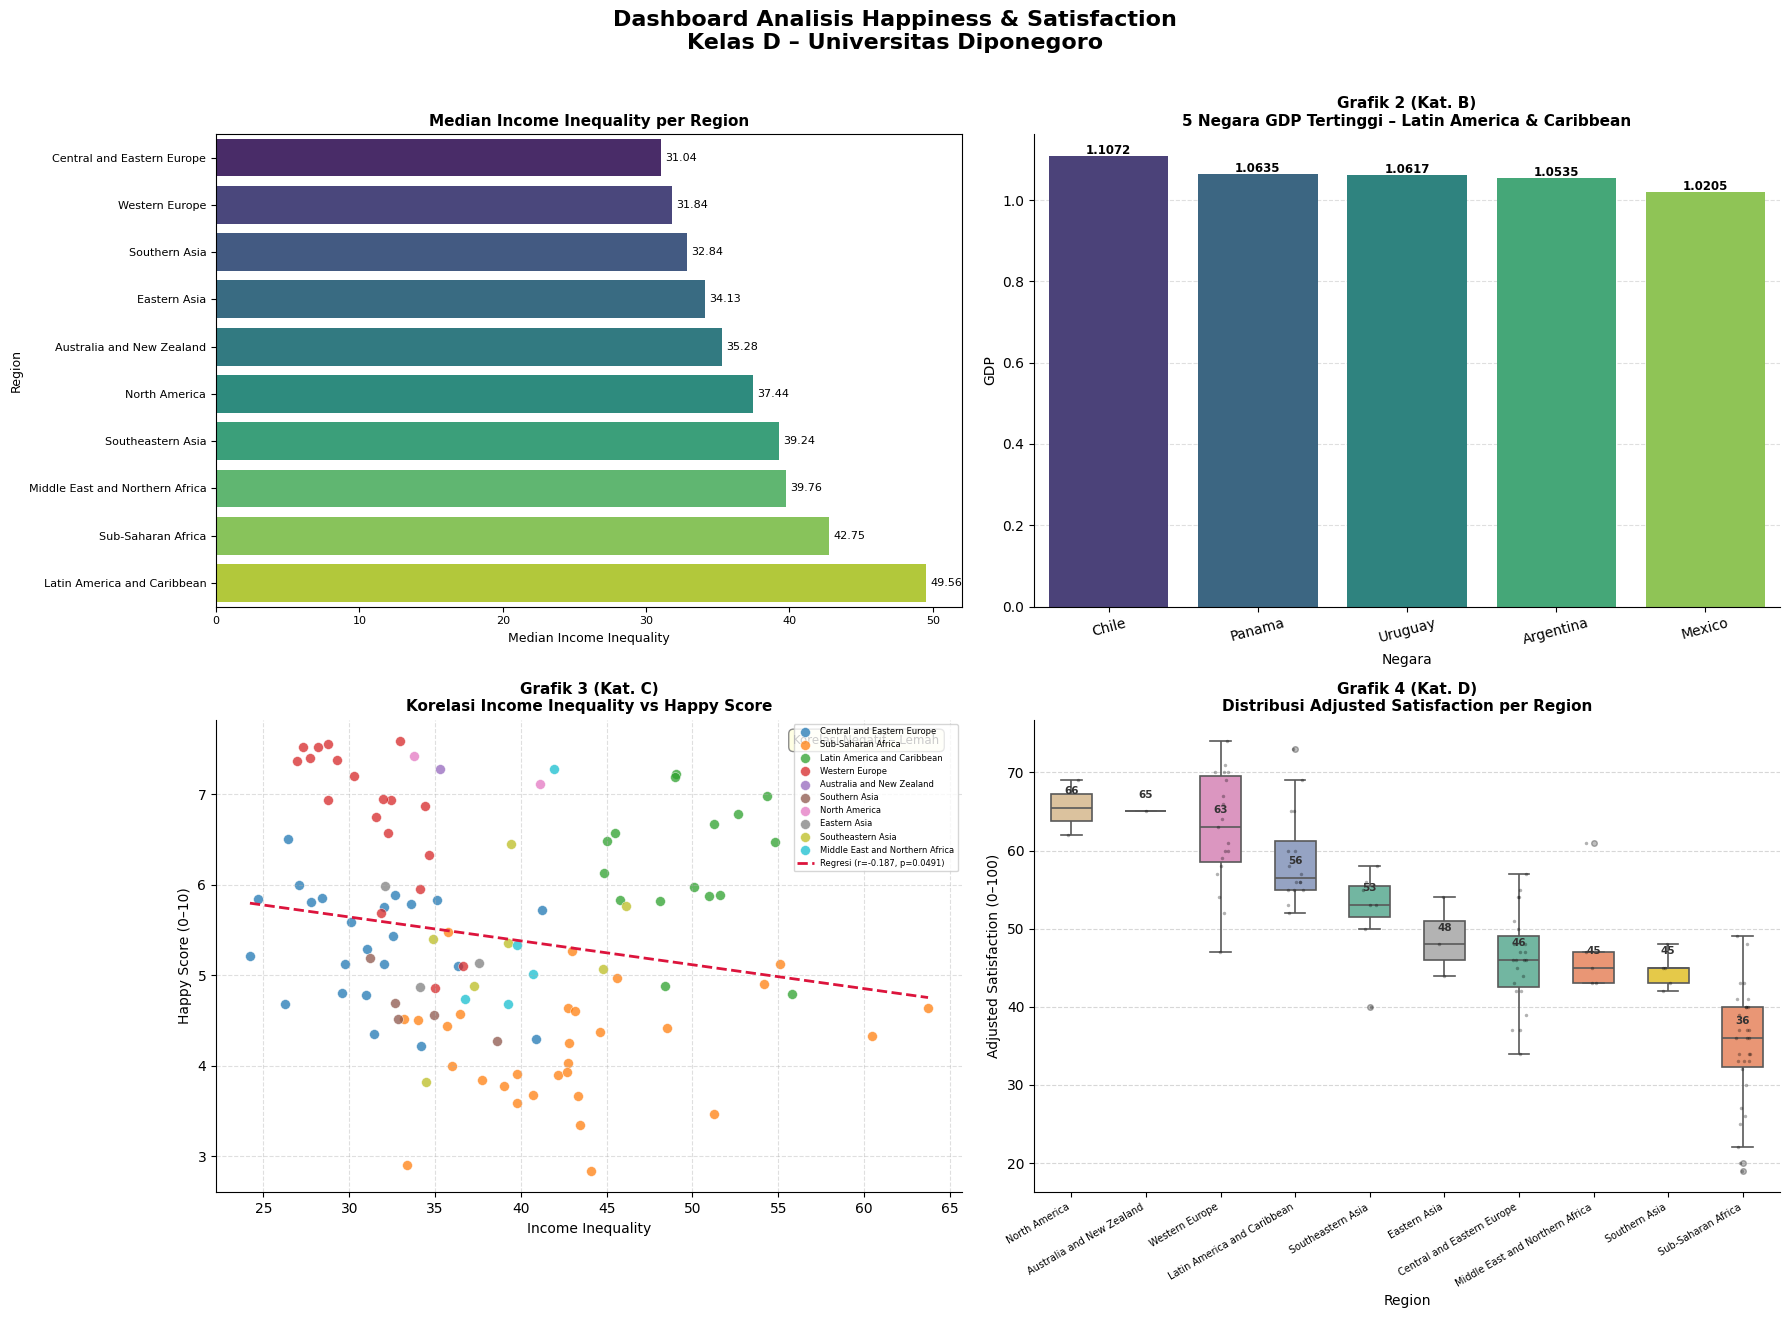

Grafik gabungan berhasil disimpan: grafik5_gabungan.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ══════════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════════
df = pd.read_csv(
    '/content/Kelas D_Happiness and Satisfaction.csv',
    sep=';',
    decimal=','
)

df.columns = df.columns.str.strip()
df['Region'] = df['Region'].str.strip().str.strip("'")

# ══════════════════════════════════════════════════════════════════
# GRAFIK 5 (GABUNGAN) — plt.subplots(2, 2)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    'Dashboard Analisis Happiness & Satisfaction\nKelas D – Universitas Diponegoro',
    fontsize=16, fontweight='bold', y=1.01
)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 1 (Kategori A) — Horizontal Bar Chart
# Median Income Inequality per Region
# ─────────────────────────────────────────────────────────────────
ax = axes[0, 0]

median_ineq = df.groupby('Region')['income_inequality'].median().reset_index()
median_ineq.columns = ['Region', 'Median_Income_Inequality']
median_ineq = median_ineq.sort_values('Median_Income_Inequality', ascending=True)

sns.barplot(
    data=median_ineq,
    x='Median_Income_Inequality',
    y='Region',
    palette='viridis',
    ax=ax
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=8, xytext=(3, 0),
        textcoords='offset points'
    )

ax.set_title('Median Income Inequality per Region', fontsize=11, fontweight='bold')
ax.set_xlabel('Median Income Inequality', fontsize=9)
ax.set_ylabel('Region', fontsize=9)
ax.tick_params(labelsize=8)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 2 (Kategori B) — Bar Chart
# 5 Negara GDP Tertinggi di Latin America and Caribbean
# ─────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]

lac_data = df[df['Region'] == 'Latin America and Caribbean'].copy()
lac_data['GDP'] = pd.to_numeric(lac_data['GDP'], errors='coerce')
top5_lac = lac_data.nlargest(5, 'GDP')

sns.barplot(
    x='Country', y='GDP',
    data=top5_lac,
    hue='Country', palette='viridis', legend=False,
    ax=ax2
)
for idx, row in enumerate(top5_lac.itertuples()):
    ax2.text(idx, row.GDP + 0.005, f'{row.GDP:.4f}',
             ha='center', fontsize=8.5, fontweight='bold')

ax2.set_title('Grafik 2 (Kat. B)\n5 Negara GDP Tertinggi – Latin America & Caribbean',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Negara', fontsize=10)
ax2.set_ylabel('GDP', fontsize=10)
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 3 (Kategori C) — Scatter Plot
# Korelasi Income Inequality vs Happy Score
# ─────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

df_clean = df[['Country', 'Region', 'income_inequality', 'Happy Score (0-10)']].dropna()
x = df_clean['income_inequality']
y = df_clean['Happy Score (0-10)']
r, p_value = stats.pearsonr(x, y)

regions = df_clean['Region'].unique()
palette_g3 = sns.color_palette('tab10', n_colors=len(regions))
region_color = {reg: palette_g3[i] for i, reg in enumerate(regions)}

for region in regions:
    subset = df_clean[df_clean['Region'] == region]
    ax3.scatter(subset['income_inequality'], subset['Happy Score (0-10)'],
                label=region, color=region_color[region],
                alpha=0.75, edgecolors='white', linewidths=0.4, s=50)

m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax3.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
         linestyle='--', label=f'Regresi (r={r:.3f}, p={p_value:.4f})')

kekuatan = 'Kuat' if abs(r) >= 0.7 else ('Sedang' if abs(r) >= 0.4 else 'Lemah')
arah = 'Negatif' if r < 0 else 'Positif'

ax3.text(0.97, 0.97, f'Korelasi {arah} – {kekuatan}',
         transform=ax3.transAxes, fontsize=8.5, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                   edgecolor='gray', alpha=0.9))
ax3.set_xlabel('Income Inequality', fontsize=10)
ax3.set_ylabel('Happy Score (0–10)', fontsize=10)
ax3.set_title('Grafik 3 (Kat. C)\nKorelasi Income Inequality vs Happy Score',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=6, loc='upper right', framealpha=0.8, ncol=1)
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.spines[['top', 'right']].set_visible(False)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 4 (Kategori D) — Box Plot
# Distribusi Adjusted Satisfaction per Region
# ─────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

df['adjusted_satisfaction (0-100)'] = pd.to_numeric(
    df['adjusted_satisfaction (0-100)'], errors='coerce'
)
df4 = df.dropna(subset=['adjusted_satisfaction (0-100)', 'Region'])

region_order = (
    df4.groupby('Region')['adjusted_satisfaction (0-100)']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
palette_g4 = sns.color_palette('Set2', n_colors=len(region_order))

sns.boxplot(
    data=df4,
    x='Region', y='adjusted_satisfaction (0-100)',
    order=region_order,
    hue='Region', palette=palette_g4, legend=False,
    width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, linestyle='none',
                    markerfacecolor='gray', alpha=0.5),
    ax=ax4
)
sns.stripplot(
    data=df4,
    x='Region', y='adjusted_satisfaction (0-100)',
    order=region_order,
    color='black', size=2.5, alpha=0.3, jitter=True,
    ax=ax4
)
for i, region in enumerate(region_order):
    med = df4[df4['Region'] == region]['adjusted_satisfaction (0-100)'].median()
    ax4.text(i, med + 1.5, f'{med:.0f}',
             ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#333')

ax4.set_title('Grafik 4 (Kat. D)\nDistribusi Adjusted Satisfaction per Region',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Region', fontsize=10)
ax4.set_ylabel('Adjusted Satisfaction (0–100)', fontsize=10)
ax4.tick_params(axis='x', rotation=30, labelsize=7)
plt.setp(ax4.get_xticklabels(), ha='right')
ax4.yaxis.grid(True, linestyle='--', alpha=0.5)
ax4.set_axisbelow(True)
sns.despine(ax=ax4)

# ══════════════════════════════════════════════════════════════════
# SIMPAN & TAMPILKAN
# ══════════════════════════════════════════════════════════════════
plt.tight_layout()
plt.savefig('grafik5_gabungan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik gabungan berhasil disimpan: grafik5_gabungan.png")